# All mispredictions for one gloss

| EXP NO    | Model    | Split            |
|-----------|----------|------------------|
| exp000    | MViTv2_S | asl2000_cutoff_9 |

Follow-up to [eda_performers.ipynb](./eda_performers.ipynb), which only shows each
underachiever's *most common* misprediction (e.g. "before" as "former", 1/4 wrong
instances). Here one gloss is picked and every one of its instances is shown with the
model's top-k confidences, then the frames of whatever it was predicted as can be
stepped through for comparison.

Some mispredictions are label problems rather than model errors: a WLASL gloss can hold several
signs (its instances' `variation_id`), and one sign can be filed under several glosses. The
default gloss, `before`, is the worked example. Its variation-0 test instances are predicted as
`former` and `past`, which can be the same over-the-shoulder sign. See
[One sign, several glosses](../../info/WLASL_info.md#one-sign-several-glosses-eg-before--former--past).
When comparing an instance with the training instances below, check its variation first.

Dataset fields, split/set naming and gotchas: [WLASL_info.md](../../info/WLASL_info.md).

In [118]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from pydantic import TypeAdapter

from src.configs import get_class_list
from src.preprocess import Instance
from src.results import (
    format_exp_label,
    get_out_stub,
    get_stash_path,
    load_json,
)
from src.results.satnac_2026.helpers import (
    ClipView,
    SortBy,
    VariationStepper,
    instance_label,
    save_shown,
    top1_gloss,
    true_rank,
)
from src.run_types import AVAIL_SETS, CUTOFF_SPLITS, InstanceTopK
from src.stats import get_all_sets
from src.visualise2 import (
    FrameFetcher,
    PanelPosition,
    set_thesis_style,
)

## Setup

In [119]:
set_thesis_style()

split_name: CUTOFF_SPLITS = 'asl2000_cutoff_9'
set_name: AVAIL_SETS = 'test' # the set the predictions were stashed for
model_name = 'MViTv2_S'
exp_no = '000'
checkpoint_num = None # override if multiple runs of the same experiment
project_name = 'satnac_2026'

gloss = 'before' # change to inspect another gloss
pred_set_name: AVAIL_SETS = 'test' # set to browse the predicted gloss's instances from
k = 10 # bars per top-k chart, <= max_k below
as_video = False # show each clip as a video instead of a frame grid (the same target_length frames)
video_scale = 1.5 # so the clip fills its half; at 1 the k=10 chart outgrows it and the clip is padded
video_interval = 150 # ms per frame, slowed from 25 fps (40 ms): 16 sampled frames would play in 0.64 s
train_sort_by: SortBy = 'variation' # order of the train-instance video grids: by 'signer'/'variation' id, or 'none' (set order)
save_assets = True # save each viewed figure to results/outputs: frame grids as PDFs, videos as MP4s
bar_position: PanelPosition = 'right' if as_video else 'bottom' # where the top-k bar chart is placed relative to the clip 
shared_axis = True # same 0-1 confidence axis on every chart, so instances compare
target_length = 16
grid_cell_size = (2.0, 2.0) # plain plot_frame_grid only; the top-k grids size themselves


stub = get_out_stub(split_name, model_name, format_exp_label(exp_no), checkpoint_num)
classes = get_class_list()
cls_idx = classes.index(gloss)
all_sets = get_all_sets(split_name)
view = ClipView(
    classes=classes,
    k=k,
    bar_position=bar_position,
    shared_axis=shared_axis,
    num_frames=target_length,
    grid_cell_size=grid_cell_size,
    as_video=as_video,
    video_scale=video_scale,
    video_interval=video_interval,
)

## Per-instance top-k predictions

The stash from `correlation_f1.ipynb` only has each instance's top-1 prediction, so the
confidences are inferred separately. This needs the trained checkpoint.

In [120]:
topk_stash_p = get_stash_path(stub, base_name='instance_topk')
max_k = 20 # how many classes are stored per instance -- caps `k`
instance_topk_adapter = TypeAdapter(list[InstanceTopK])


def run_topk_inference() -> None:
    from src.results import stash_json
    from src.run_types import MinInfo
    from src.testing import get_model_checkpoint_dir, get_model_exp_dir
    from src.visualise2 import infer_instance_topk

    output = get_model_exp_dir(split=split_name, model=model_name, exp_no=int(exp_no))
    save_path = get_model_checkpoint_dir(output, checkpoint_num)
    admin = MinInfo(model=model_name, split=split_name, save_path=str(save_path))
    results = infer_instance_topk(admin=admin, set_name=set_name, split_name=split_name, max_k=max_k)
    stash_json(instance_topk_adapter.dump_python(results), topk_stash_p)
    print(f'Saved to: {topk_stash_p}')

# run_topk_inference()

In [121]:
predictions = {
    p.video_id: p for p in instance_topk_adapter.validate_python(load_json(topk_stash_p))
}
print(f'Loaded top-{max_k} predictions for {len(predictions)} {set_name} instances')

Loaded top-20 predictions for 2879 test instances


## Every prediction for the gloss

`True rank` is the gloss's position in the model's ranking (`>max_k` if it isn't stored).

In [122]:
gloss_instances = [Instance.model_validate(i) for i in all_sets[set_name][cls_idx]['instances']]
gloss_preds = [predictions[inst.video_id] for inst in gloss_instances]
summary_df = pd.DataFrame(
    {
        'Video ID': [inst.video_id for inst in gloss_instances],
        'Signer': [inst.signer_id for inst in gloss_instances],
        'Variation': [inst.variation_id for inst in gloss_instances],
        'Predicted': [top1_gloss(p, classes) for p in gloss_preds],
        'Confidence': [p.topk_probs[0] for p in gloss_preds],
        'True rank': [true_rank(p, max_k) for p in gloss_preds],
    }
)
print(f'"{gloss}": {len(gloss_instances)} {set_name} instances')
display(Counter(summary_df['Predicted']).most_common())
summary_df

"before": 4 test instances


[('former', 1), ('beside', 1), ('next', 1), ('past', 1)]

,Video ID,Signer,Variation,Predicted,Confidence,True rank
0,05735,20,0,former,0.374887,>20
1,05727,38,1,beside,0.225988,>20
2,05739,10,1,next,0.571334,3
3,05741,11,0,past,0.735536,3


## Step through the gloss's instances

Run the first cell once, then re-run the second to show the next instance (wraps around
after the last). Each shows the clip (a frame grid, or a video if `as_video`) with its top-k confidences, the true gloss's bar in
green when it's among them, and sets `predicted_gloss` for the section below.

In [123]:
gloss_fetcher = FrameFetcher(
    cycle=True,
    cls_idx=cls_idx,
    all_sets=all_sets,
    set_name=set_name,
    split_name=split_name,
    target_length=target_length,
)
pred_fetcher: FrameFetcher | None = None # built by the predicted-gloss viewer below
pred_fetcher_gloss: str | None = None

Instance 1/4: video 05735, signer 20, variation 0
Predicted "former" (0.37); "before" ranked >20
Saved: topk_before_05735_asl2000_cutoff_9_MViTv2_S_exp000_.pdf


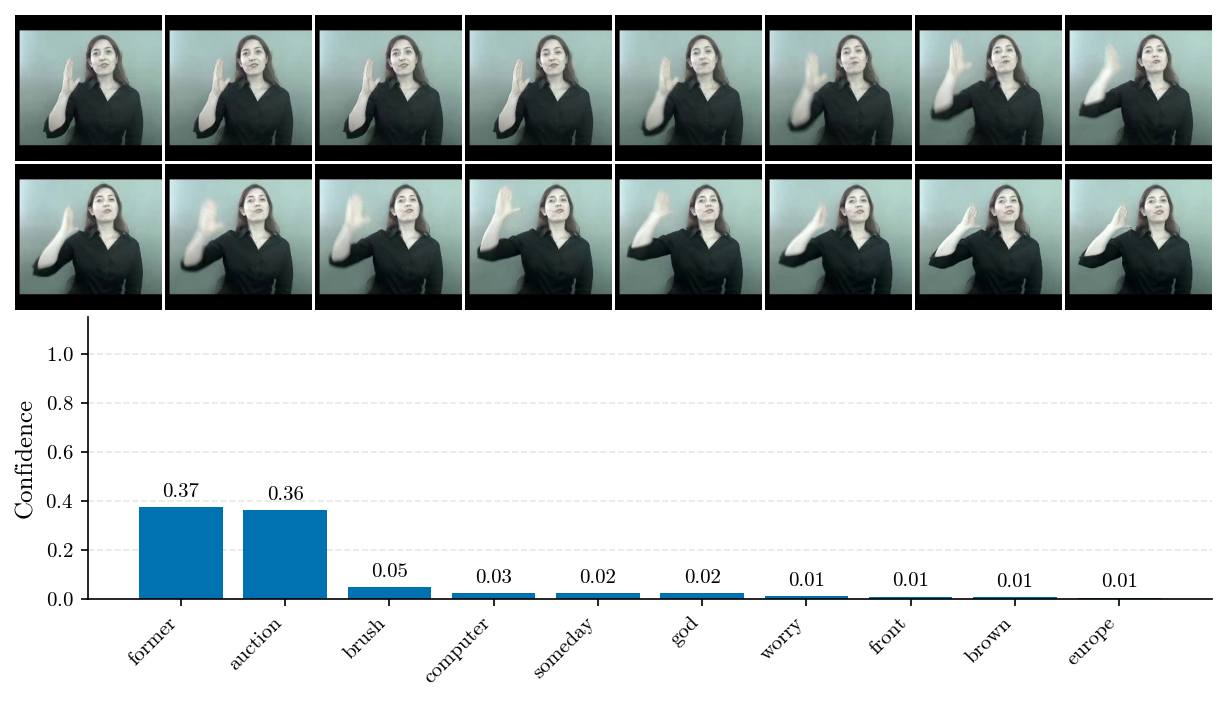

In [124]:
frames = gloss_fetcher()
inst = gloss_fetcher.current_instance
pred = predictions[inst.video_id]
predicted_gloss = top1_gloss(pred, classes)

print(f'Instance {gloss_fetcher.cur_idx}/{gloss_fetcher.len}: video {inst.video_id}, {instance_label(inst)}')
print(f'Predicted "{predicted_gloss}" ({pred.topk_probs[0]:.2f}); "{gloss}" ranked {true_rank(pred, max_k)}')
shown = view.show_topk(frames, pred, true_label=gloss)
if save_assets:
    print(f'Saved: {save_shown(shown, f"topk_{gloss}_{inst.video_id}", stub, project_name).name}')

## Step through the predicted gloss's instances

Re-run to show the next instance of the current `predicted_gloss`. It restarts from that
gloss's first instance whenever the cell above moves to an instance predicted as
something else. Instances from `set_name` also get their own top-k chart.

"former" instance 1/1: video 23029, signer 9, variation 0
Saved: topk_former_23029_asl2000_cutoff_9_MViTv2_S_exp000_.pdf


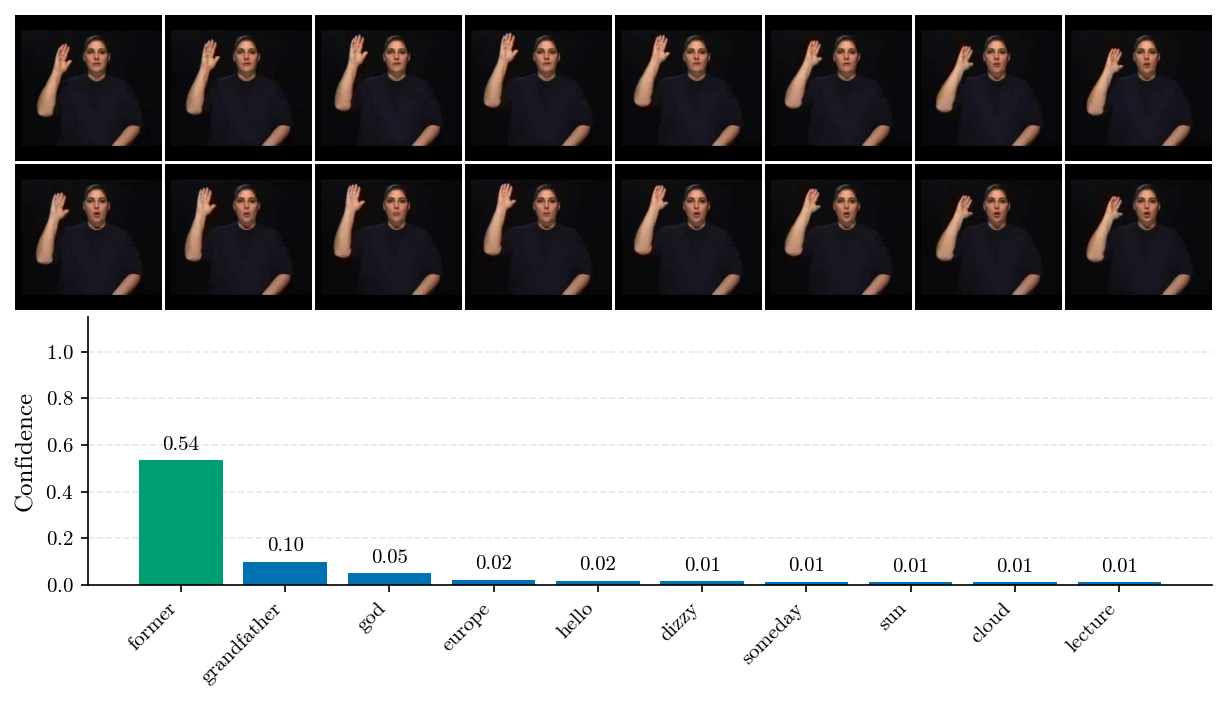

In [125]:
# assigned unconditionally: rebinding it under an `if` makes Pylance flag it as possibly unbound
pred_fetcher = (
    pred_fetcher
    if pred_fetcher is not None and pred_fetcher_gloss == predicted_gloss
    else FrameFetcher(
        cycle=True,
        cls_idx=classes.index(predicted_gloss),
        all_sets=all_sets,
        set_name=pred_set_name,
        split_name=split_name,
        target_length=target_length,
    )
)
pred_fetcher_gloss = predicted_gloss

if pred_fetcher.len == 0:
    print(f'"{predicted_gloss}" has no {pred_set_name} instances')
else:
    pred_frames = pred_fetcher()
    pred_inst = pred_fetcher.current_instance
    print(f'"{predicted_gloss}" instance {pred_fetcher.cur_idx}/{pred_fetcher.len}: video {pred_inst.video_id}, {instance_label(pred_inst)}')
    if pred_set_name == set_name:
        shown = view.show_topk(pred_frames, predictions[pred_inst.video_id], true_label=predicted_gloss)
        asset_name = f"topk_{predicted_gloss}_{pred_inst.video_id}"
    else:
        shown = view.show_clip(pred_frames)
        asset_name = f"{pred_set_name}_{predicted_gloss}_{pred_inst.video_id}"
    if save_assets:
        print(f'Saved: {save_shown(shown, asset_name, stub, project_name).name}')

## Training instances of the true gloss

Every `train` instance of `gloss`, sampled as at test time (centre crop, `target_length` frames),
not with training augmentations.

* **Stills** (`as_video = False`): run the first cell once, then re-run the second to step through
  the instances one per variation: a frame grid of the next instance of each of the gloss's signs
  (`variation_id`), in variation order, so the test instance above can be matched to one. A
  variation that runs out drops out until the one with the most has too, then all restart. With
  `save_assets`, each grid is saved.
* **Videos**: the first cell plays every instance at once, titled by signer and variation and
  ordered by `train_sort_by`; by variation, a gloss's different signs sit together. With
  `save_assets`, the video is saved.

In [126]:
def show_variation_step(steps: VariationStepper, gloss_name: str) -> None:
    """Show (and with `save_assets`, save) the next instance of each of a gloss's variations."""
    for pick in steps():
        inst = pick.instance
        print(
            f'"{gloss_name}" variation {inst.variation_id}: instance {pick.position}/{pick.total}, '
            f'video {inst.video_id}, signer {inst.signer_id}'
        )
        shown = view.show_clip(pick.frames)
        if save_assets:
            asset_name = f"train_{gloss_name}_var{inst.variation_id}_{inst.video_id}"
            print(f'Saved: {save_shown(shown, asset_name, stub, project_name).name}')
        plt.show() # one grid after each label, rather than all at the end of the cell


true_train = FrameFetcher(
    cls_idx=cls_idx,
    all_sets=all_sets,
    set_name='train',
    split_name=split_name,
    target_length=target_length,
).fetch_all()
true_steps = VariationStepper(true_train)
print(f'"{gloss}": {len(true_train)} train instances, per variation: {true_steps.counts()}')
if as_video:
    shown = view.show_instances(true_train, title=f'Train instances of {gloss} ({len(true_train)})', sort_by=train_sort_by)
    if save_assets:
        print(f'Saved: {save_shown(shown, f"train_{gloss}_all_by_{train_sort_by}", stub, project_name).name}')

"before": 18 train instances, per variation: {0: 10, 1: 8}


"before" variation 0: instance 10/10, video 05743, signer 11
Saved: train_before_var0_05743_asl2000_cutoff_9_MViTv2_S_exp000_.pdf


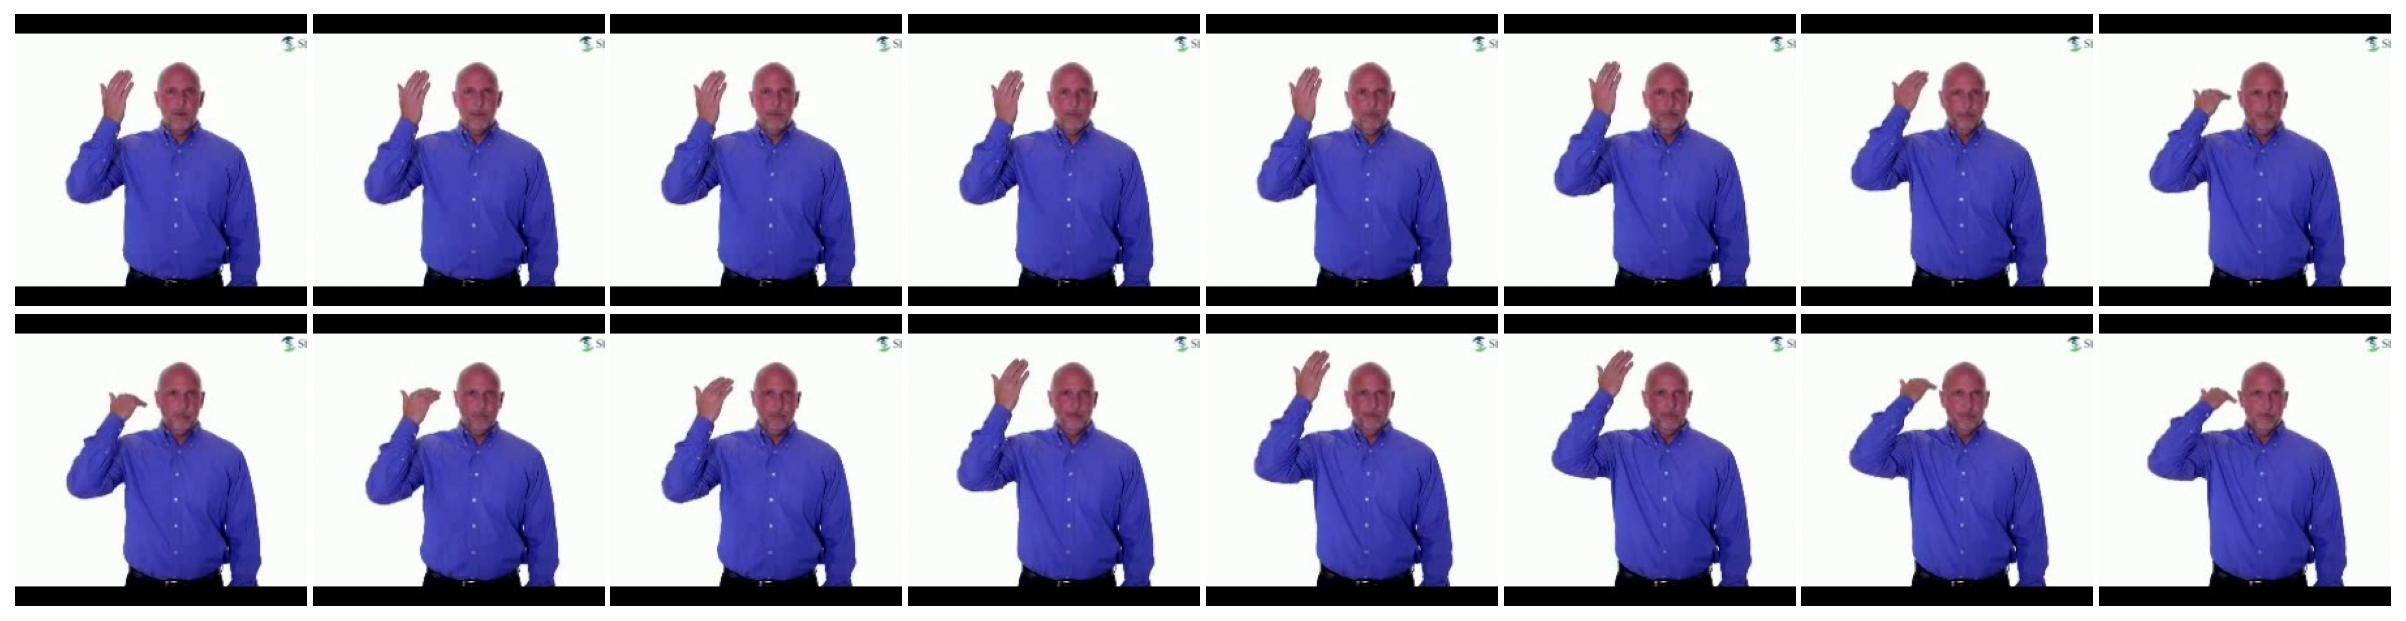

In [138]:
if as_video:
    print('as_video: every instance is shown above')
else:
    show_variation_step(true_steps, gloss)

## Training instances of the predicted gloss

As above, for `predicted_gloss`. Re-run the first cell after stepping to an instance predicted
as something else.

In [139]:
# predicted_gloss = 'past'
pred_train = FrameFetcher(
    cls_idx=classes.index(predicted_gloss),
    all_sets=all_sets,
    set_name='train',
    split_name=split_name,
    target_length=target_length,
).fetch_all()
pred_steps = VariationStepper(pred_train)
print(f'"{predicted_gloss}": {len(pred_train)} train instances, per variation: {pred_steps.counts()}')
if as_video:
    shown = view.show_instances(pred_train, title=f'Train instances of {predicted_gloss} ({len(pred_train)})', sort_by=train_sort_by)
    if save_assets:
        print(f'Saved: {save_shown(shown, f"train_{predicted_gloss}_all_by_{train_sort_by}", stub, project_name).name}')

"past": 10 train instances, per variation: {0: 10}


"past" variation 0: instance 3/10, video 41454, signer 11
Saved: train_past_var0_41454_asl2000_cutoff_9_MViTv2_S_exp000_.pdf


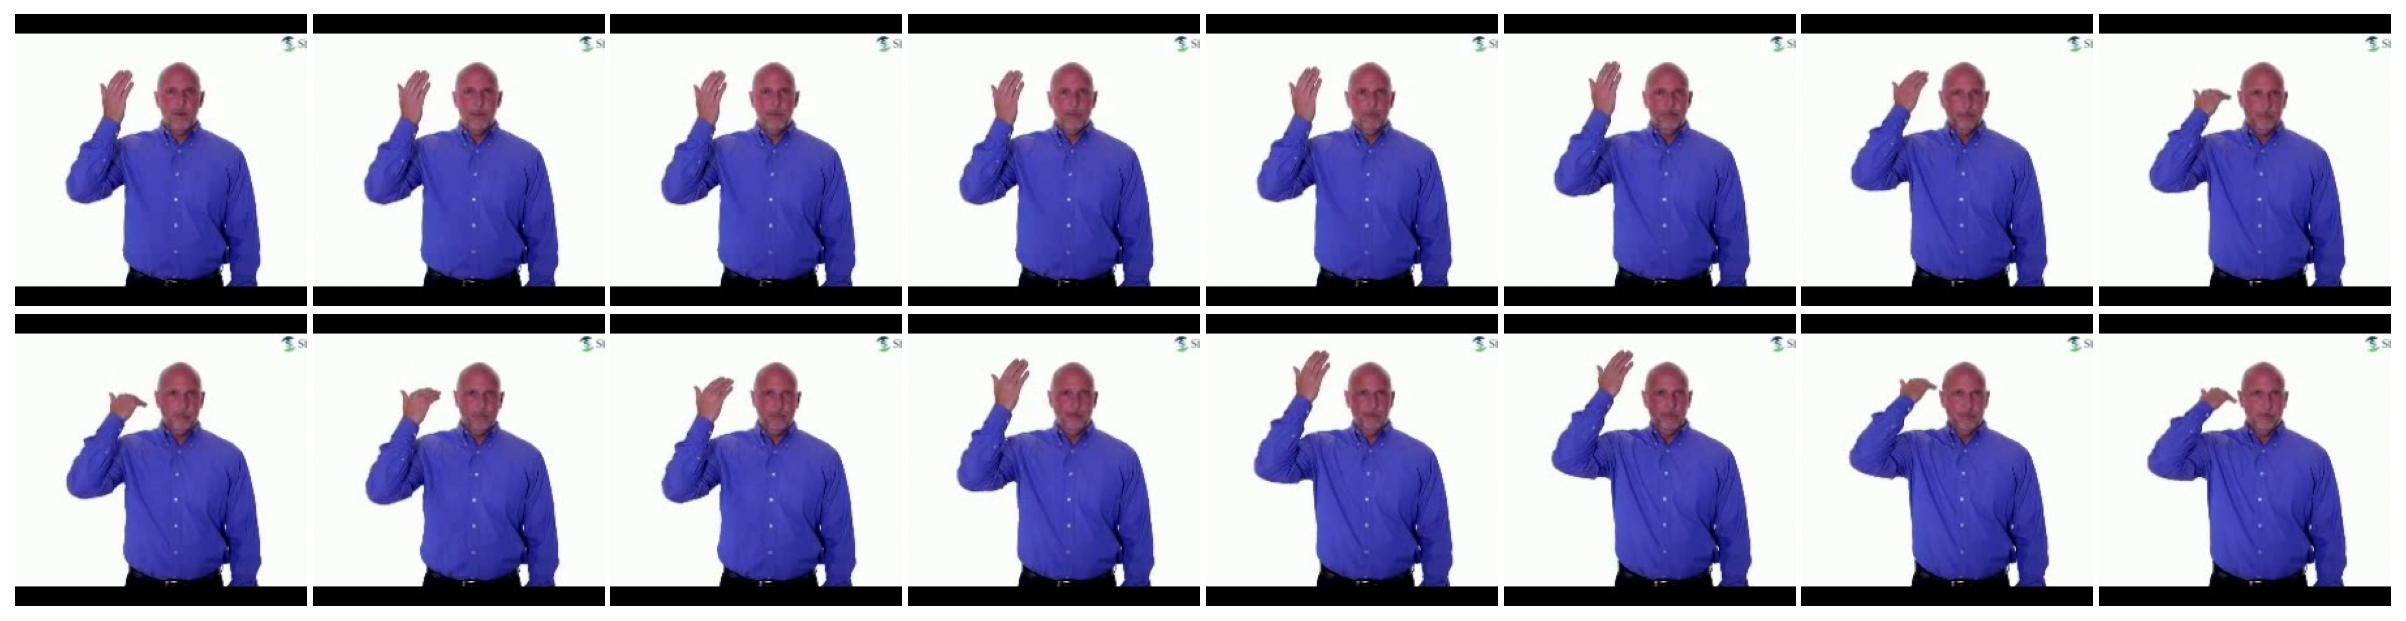

In [142]:
if as_video:
    print('as_video: every instance is shown above')
else:
    show_variation_step(pred_steps, predicted_gloss)